# JPMC Take Home Project

**Name:** Shivani Madan

**Email ID:** shivanimadan1099@gmail.com

---

# 2. Customer Segmentation Analysis

## Library Imports and Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy import stats
import pandas as pd
from IPython.display import display

In [2]:
df = pd.read_csv('after_feature_engineering.csv', index_col=0)

In [3]:
df.columns

Index(['age', 'class of worker', 'detailed industry recode', 'education',
       'wage per hour', 'marital stat', 'major industry code', 'race',
       'hispanic origin', 'sex', 'full or part time employment stat',
       'capital gains', 'capital losses', 'dividends from stocks',
       'tax filer stat', 'region of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'live in this house 1 year ago', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year', 'label', 'age_group',
       'has_migration_data', 'country_of_birth_father_region',
       'country_of_birth_mother_region', 'country_of_birth_self_region',
       'age_category', 'net_capital', 'is_self_employed',
       'has_veteran_benefits',

## Feature Selection


In [4]:
features_to_drop = [
    'label',
    'weight',

    'capital gains',  # I have 'net_capital'
    'capital losses',  
    'wage per hour',  
    'dividends from stocks',  
    'own business or self employed',  
    'veterans benefits',  
    'age',  
    'education',
    'age_category',

    'region of previous residence',
    'major industry code',

    'country of birth father',  # I have 'country_of_birth_father_region'
    'country of birth mother',  
    'country of birth self',  
    
    'detailed industry recode',
    'detailed household and family stat',
    'detailed household summary in household',
    'year',
]

In [5]:
df1 = df.drop(columns=features_to_drop)

In [6]:
total = len(df1)

# Mom Region not equal to Dad Region
mom_dad_diff_pct = ((df1['country_of_birth_father_region'] != df1['country_of_birth_mother_region']).sum() / total * 100)

# All three different
all_diff_pct = (
    ((df1['country_of_birth_father_region'] != df1['country_of_birth_mother_region']) &
     (df1['country_of_birth_father_region'] != df1['country_of_birth_self_region']) &
     (df1['country_of_birth_mother_region'] != df1['country_of_birth_self_region'])).sum() / total * 100
)

# All three same
all_same_pct = (
    ((df1['country_of_birth_father_region'] == df1['country_of_birth_mother_region']) &
     (df1['country_of_birth_father_region'] == df1['country_of_birth_self_region'])).sum() / total * 100
)

parents_same_self_different = (
    (df1['country_of_birth_father_region'] == df1['country_of_birth_mother_region']) &
    (df1['country_of_birth_father_region'] != df1['country_of_birth_self_region'])
).sum() / len(df) * 100

print(f"Mom and Dad different regions: {mom_dad_diff_pct:.2f}%")
print(f"All three different regions: {all_diff_pct:.2f}%")
print(f"All three same region: {all_same_pct:.2f}%")
print(f"Parents same region, Self different: {parents_same_self_different:.2f}%")

Mom and Dad different regions: 5.07%
All three different regions: 0.44%
All three same region: 90.11%
Parents same region, Self different: 4.82%


In [7]:
numerical_cols = df1.select_dtypes(include=[np.number]).columns
corr_matrix = df1[numerical_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

corr_matrix

,num persons worked for employer,weeks worked in year,has_migration_data,net_capital,is_self_employed,has_veteran_benefits,education_level,wage_per_hour_capped,dividends_capped
num persons worked for employer,1.000000,0.747302,0.006206,0.053011,0.242235,0.461744,0.531932,0.203764,0.009510
weeks worked in year,0.747302,1.000000,0.009175,0.077530,0.273682,0.529993,0.607783,0.207900,0.016311
has_migration_data,0.006206,0.009175,1.000000,0.003943,0.004197,0.023998,0.017421,0.000304,0.000196
net_capital,0.053011,0.077530,0.003943,1.000000,0.019374,0.047116,0.093902,0.001648,0.120166
is_self_employed,0.242235,0.273682,0.004197,0.019374,1.000000,0.180330,0.217003,0.058350,0.002082
has_veteran_benefits,0.461744,0.529993,0.023998,0.047116,0.180330,1.000000,0.835582,0.119392,0.074074
education_level,0.531932,0.607783,0.017421,0.093902,0.217003,0.835582,1.000000,0.122810,0.126219
wage_per_hour_capped,0.203764,0.207900,0.000304,0.001648,0.058350,0.119392,0.122810,1.000000,0.007500
dividends_capped,0.009510,0.016311,0.000196,0.120166,0.002082,0.074074,0.126219,0.007500,1.000000


In [8]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

categorical_cols = ['class of worker','marital stat','race','hispanic origin','sex','full or part time employment stat','tax filer stat','live in this house 1 year ago','citizenship',
                    'age_group','has_migration_data','country_of_birth_father_region','country_of_birth_mother_region','country_of_birth_self_region','education_level']
for i in range(len(categorical_cols)):
    for j in range(i+1, len(categorical_cols)):
        v = cramers_v(df1[categorical_cols[i]], df1[categorical_cols[j]])
        if v > 0.7:  # Strong association
            print(f"{categorical_cols[i]} - {categorical_cols[j]}: {v:.3f}")


full or part time employment stat - has_migration_data: 0.771
live in this house 1 year ago - has_migration_data: 1.000
country_of_birth_father_region - country_of_birth_mother_region: 0.765


In [9]:
features_to_drop = [
    'country_of_birth_father_region',
    'country_of_birth_mother_region',
    'num persons worked for employer',
    'has_veteran_benefits',
    'live in this house 1 year ago',
    'has_veteran_benefits',
    'hispanic origin',
    'tax filer stat',
    'citizenship',
    'has_migration_data'
]

In [10]:
X_segment = df1.drop(columns=features_to_drop)

print(f"Features after selection: {X_segment.shape[1]}")
print(X_segment.columns.tolist())

Features after selection: 14
['class of worker', 'marital stat', 'race', 'sex', 'full or part time employment stat', 'family members under 18', 'weeks worked in year', 'age_group', 'country_of_birth_self_region', 'net_capital', 'is_self_employed', 'education_level', 'wage_per_hour_capped', 'dividends_capped']


In [11]:
categorical_to_encode = [
    'class of worker',
    'marital stat',
    'race',
    'sex',
    'full or part time employment stat',
    'age_group',
    'country_of_birth_self_region',
    'family members under 18',
]

In [12]:
numerical_features = X_segment .select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X_segment .select_dtypes(include=['object', 'category']).columns.tolist()

In [13]:
X_encoded = pd.get_dummies(
    X_segment, 
    columns=categorical_to_encode, 
    drop_first=True, 
    dtype=int
)

print(f"Shape after one-hot encoding: {X_encoded.shape}")
print(f"Original features: {len(categorical_features) + len(numerical_features)}")
print(f"After encoding: {X_encoded.shape[1]} features")

Shape after one-hot encoding: (199523, 47)
Original features: 14
After encoding: 47 features


## Feature Scaling


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
    
print(f"✓ Scaled shape: {X_scaled.shape}")

✓ Scaled shape: (199523, 47)


In [15]:
X_ready, scaler, feature_names = X_scaled, scaler, X_encoded.columns

## Dimensionality Reduction


Applied Principal Component Analysis (PCA) to reduce dimensionality while retaining the maximum variance.

PCA ANALYSIS FOR DIMENSIONALITY REDUCTION

Original dimensions: 47

Components needed to explain:
  90% variance: 33 components
  95% variance: 36 components
  99% variance: 41 components
  80% variance: 28 components
  70% variance: 23 components


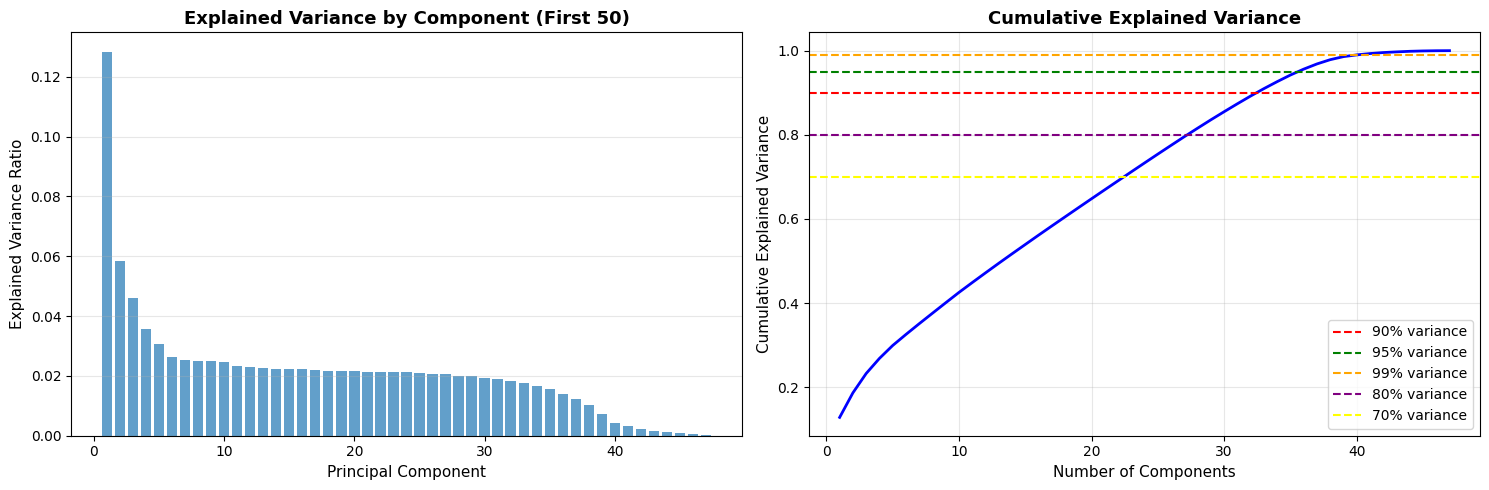

In [16]:
print("PCA ANALYSIS FOR DIMENSIONALITY REDUCTION")

pca_full = PCA(random_state=42)
pca_full.fit(X_ready)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_70 = np.argmax(cumulative_variance >= 0.70) + 1

print(f"\nOriginal dimensions: {X_ready.shape[1]}")
print(f"\nComponents needed to explain:")
print(f"  90% variance: {n_components_90} components")
print(f"  95% variance: {n_components_95} components")
print(f"  99% variance: {n_components_99} components")
print(f"  80% variance: {n_components_80} components")
print(f"  70% variance: {n_components_70} components")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(range(1, min(51, len(pca_full.explained_variance_ratio_)+1)), 
        pca_full.explained_variance_ratio_[:50], alpha=0.7)
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance Ratio', fontsize=11)
ax1.set_title('Explained Variance by Component (First 50)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
ax2.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
ax2.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
ax2.axhline(y=0.99, color='orange', linestyle='--', label='99% variance')
ax2.axhline(y=0.80, color='purple', linestyle='--', label='80% variance')
ax2.axhline(y=0.70, color='yellow', linestyle='--', label='70% variance')
ax2.set_xlabel('Number of Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11)
ax2.set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
n_components_optimal = n_components_70

print(f"Dimensionality reduction: {X_ready.shape[1]} → {n_components_optimal}")
print(f"Reduction: {(1 - n_components_optimal/X_ready.shape[1])*100:.1f}%")

Dimensionality reduction: 47 → 23
Reduction: 51.1%


In [18]:
pca = PCA(n_components=n_components_optimal, random_state=42)
X_pca = pca.fit_transform(X_ready)

print(f"\nPCA transformation complete!")
print(f"   Original shape: {X_ready.shape}")
print(f"   PCA shape: {X_pca.shape}")
print(f"   Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

print(f"\nTop 10 components variance:")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"   PC{i+1}: {pca.explained_variance_ratio_[i]:.3%}")



PCA transformation complete!
   Original shape: (199523, 47)
   PCA shape: (199523, 23)
   Total variance explained: 71.04%

Top 10 components variance:
   PC1: 12.845%
   PC2: 5.835%
   PC3: 4.594%
   PC4: 3.584%
   PC5: 3.069%
   PC6: 2.626%
   PC7: 2.545%
   PC8: 2.489%
   PC9: 2.481%
   PC10: 2.426%


## Determining Optimal Number of Clusters (K Value) 


### Elbow Method


In [19]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

print("Testing different K values...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}")


Testing different K values...
K=2: Inertia=5658368.08
K=3: Inertia=5140045.87
K=4: Inertia=4851963.28
K=5: Inertia=4737664.38
K=6: Inertia=4527271.98
K=7: Inertia=4378110.77
K=8: Inertia=4199089.70
K=9: Inertia=3971623.54
K=10: Inertia=3868035.55


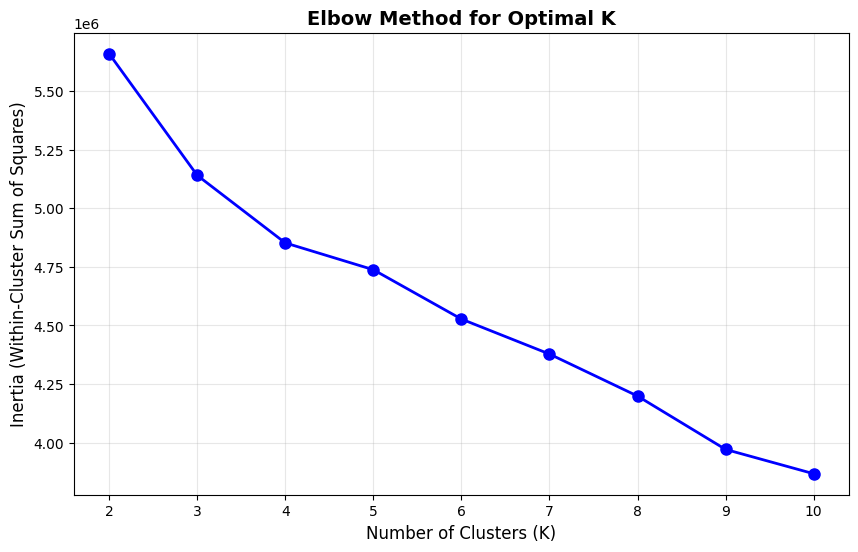

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

### Silhouette Analysis


Evaluating cluster quality using Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score.

In [21]:
silhouette_scores = []

print("Calculating Silhouette Scores...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels, sample_size=10000)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score={score:.4f}")

# Find optimal K
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal K: {optimal_k}")
print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")


Calculating Silhouette Scores...
K=2: Silhouette Score=0.2020
K=3: Silhouette Score=0.2196
K=4: Silhouette Score=0.2149
K=5: Silhouette Score=0.2185
K=6: Silhouette Score=0.2313
K=7: Silhouette Score=0.2281
K=8: Silhouette Score=0.2602
K=9: Silhouette Score=0.2456
K=10: Silhouette Score=0.2814

Optimal K: 10
Best Silhouette Score: 0.2814


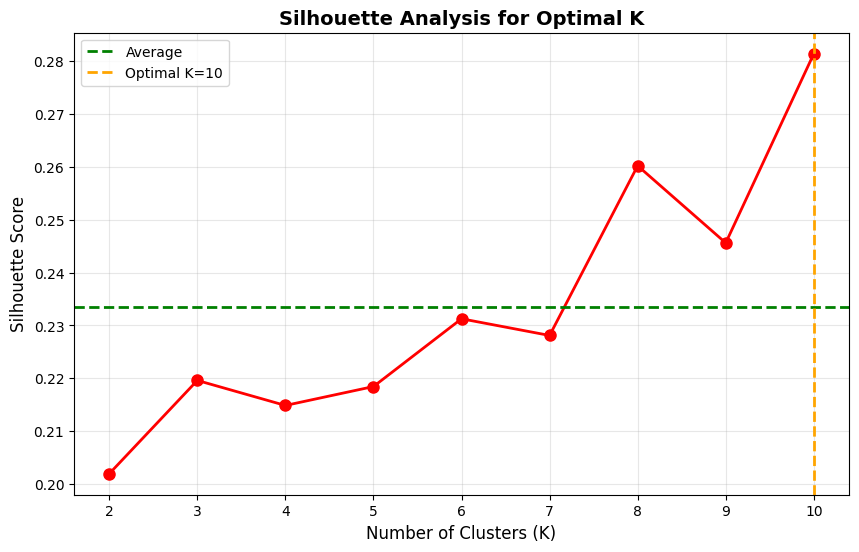

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Analysis for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.axhline(y=np.mean(silhouette_scores), color='g', linestyle='--', label='Average', linewidth=2)
plt.axvline(x=optimal_k, color='orange', linestyle='--', label=f'Optimal K={optimal_k}', linewidth=2)
plt.legend()
plt.show()

## Training

In [23]:
# Training the model with k = 4 due to domain knowledge and statistical analysis 
optimal_k = 4
print(f"Training K-Means with K={optimal_k}...")

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

clusters = kmeans_final.fit_predict(X_pca)

print(f"Model trained successfully!")
print(f"Inertia: {kmeans_final.inertia_:.2f}")
print(f"Iterations: {kmeans_final.n_iter_}")

Training K-Means with K=4...
Model trained successfully!
Inertia: 4851963.28
Iterations: 11


In [24]:
# Adding cluster labels to dataframe
df['cluster'] = clusters

print("\nCluster Percentages:")
print((df['cluster'].value_counts(normalize=True).sort_index() * 100).round(2))


Cluster Percentages:
cluster
0     7.59
1    20.74
2    27.54
3    44.13
Name: proportion, dtype: float64


## Model Evaluation


In [25]:
print("MODEL EVALUATION METRICS")

# Silhouette Score 
silhouette = silhouette_score(X_pca, clusters, sample_size=10000)
print(f"Silhouette Score: {silhouette:.4f}")

# Calinski-Harabasz Score 
calinski = calinski_harabasz_score(X_pca, clusters)
print(f"\nCalinski-Harabasz Score: {calinski:.2f}")

# Davies-Bouldin Score 
davies = davies_bouldin_score(X_pca, clusters)
print(f"\nDavies-Bouldin Score: {davies:.4f}")

MODEL EVALUATION METRICS
Silhouette Score: 0.2159

Calinski-Harabasz Score: 24802.10

Davies-Bouldin Score: 1.9494


## Cluster Visualization


Visualizing clusters in reduced dimensional space using PCA components.

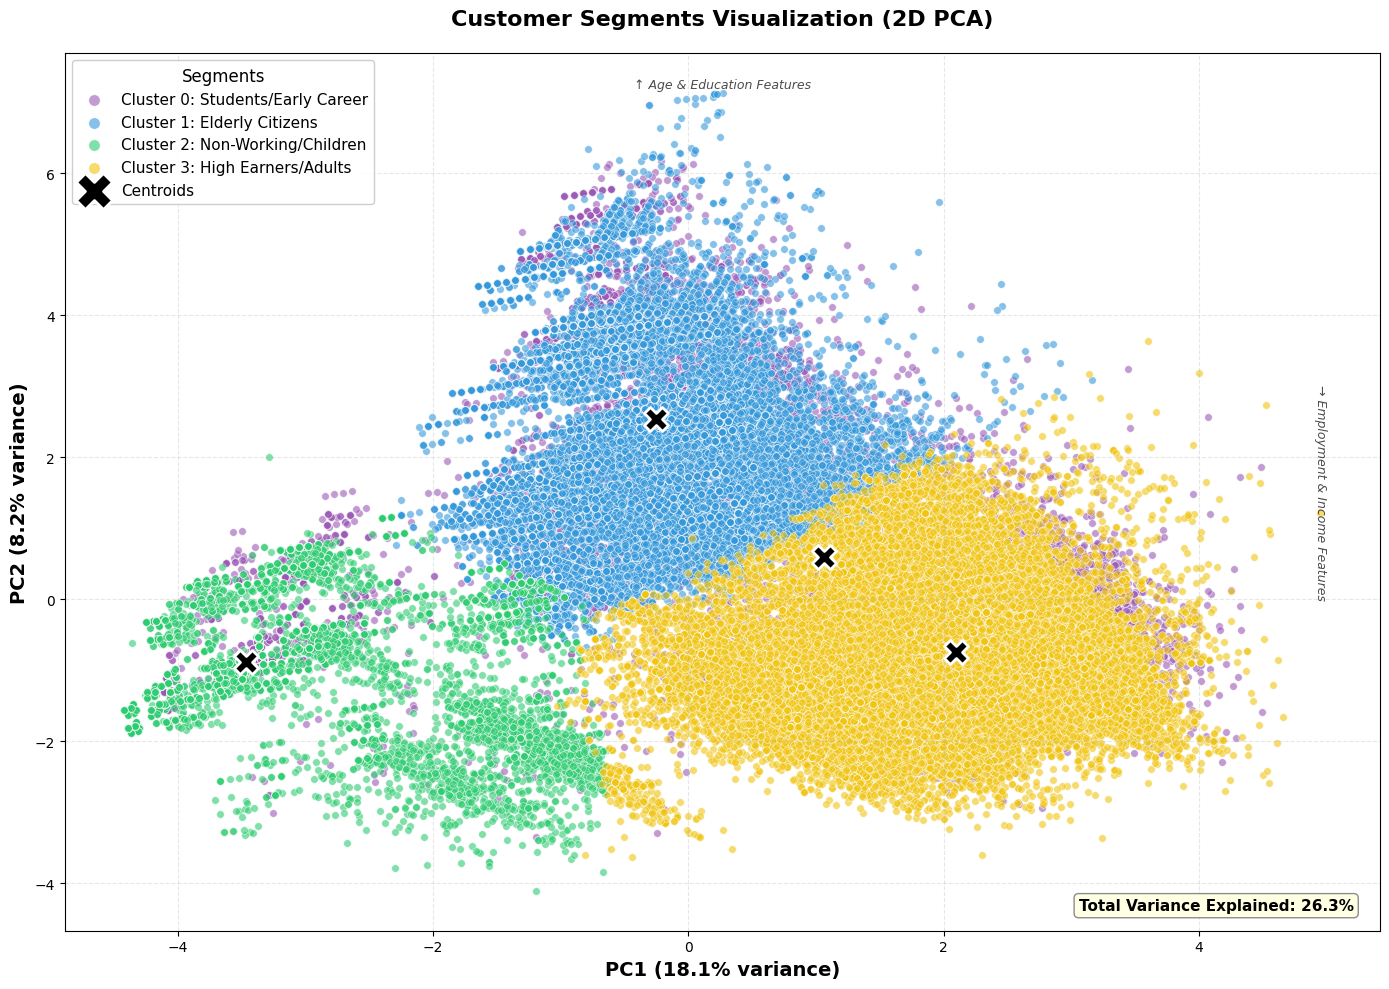


CLUSTER DISTRIBUTION
Cluster 0: Students/Early Career        : 15,148 (  7.6%)
Cluster 1: Elderly Citizens             : 41,381 ( 20.7%)
Cluster 2: Non-Working/Children         : 54,950 ( 27.5%)
Cluster 3: High Earners/Adults          : 88,044 ( 44.1%)

PCA COMPONENT INTERPRETATION

PC1 (Horizontal): 18.1% variance
  → Primary driver: Employment status, income level, work intensity

PC2 (Vertical): 8.2% variance
  → Primary driver: Age, education level, life stage

Combined Variance: 26.3%
  → Captures core socioeconomic dimensions


In [38]:
plt.figure(figsize=(14, 10))

colors = ['#9b59b6', '#3498db', '#2ecc71', '#f1c40f']  # Purple, Blue, Green, Yellow
cluster_names = {
    0: 'Cluster 0: Students/Early Career',
    1: 'Cluster 1: Elderly Citizens', 
    2: 'Cluster 2: Non-Working/Children',
    3: 'Cluster 3: High Earners/Adults'
}

for cluster_id in sorted(np.unique(clusters)):
    mask = clusters == cluster_id
    plt.scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1],
        c=colors[cluster_id],
        label=cluster_names.get(cluster_id, f'Cluster {cluster_id}'),
        alpha=0.6,
        s=30,
        edgecolors='white',
        linewidth=0.5
    )


for cluster_id in sorted(np.unique(clusters)):
    mask = clusters == cluster_id
    centroid_x = X_pca_2d[mask, 0].mean()
    centroid_y = X_pca_2d[mask, 1].mean()
    plt.scatter(
        centroid_x, 
        centroid_y,
        c='black',
        marker='X',
        s=300,
        edgecolors='white',
        linewidth=2,
        zorder=5
    )


plt.scatter([], [], c='black', marker='X', s=300, 
           edgecolors='white', linewidth=2, label='Centroids')


plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', 
           fontsize=14, fontweight='bold')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', 
           fontsize=14, fontweight='bold')


plt.title('Customer Segments Visualization (2D PCA)', 
          fontsize=16, fontweight='bold', pad=20)


plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(loc='upper left', fontsize=11, framealpha=0.95, 
           title='Segments', title_fontsize=12, markerscale=1.5)

total_variance = pca_2d.explained_variance_ratio_[0] + pca_2d.explained_variance_ratio_[1]
variance_text = f"Total Variance Explained: {total_variance:.1%}"
plt.text(0.98, 0.02, variance_text, 
         transform=plt.gca().transAxes,
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='gray'),
         ha='right', va='bottom')


plt.text(0.95, 0.5, '→ Employment & Income Features', 
         transform=plt.gca().transAxes,
         fontsize=9, style='italic', alpha=0.7, rotation=-90, va='center')
plt.text(0.5, 0.96, '↑ Age & Education Features', 
         transform=plt.gca().transAxes,
         fontsize=9, style='italic', alpha=0.7, ha='center')

plt.tight_layout()
plt.show()


print("\n" + "="*70)
print("CLUSTER DISTRIBUTION")
print("="*70)
unique, counts = np.unique(clusters, return_counts=True)
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(clusters)) * 100
    print(f"{cluster_names.get(cluster_id, f'Cluster {cluster_id}'):40s}: {count:6,} ({percentage:5.1f}%)")

print("\n" + "="*70)
print("PCA COMPONENT INTERPRETATION")
print("="*70)
print(f"\nPC1 (Horizontal): {pca_2d.explained_variance_ratio_[0]:.1%} variance")
print("  → Primary driver: Employment status, income level, work intensity")
print(f"\nPC2 (Vertical): {pca_2d.explained_variance_ratio_[1]:.1%} variance")
print("  → Primary driver: Age, education level, life stage")
print(f"\nCombined Variance: {total_variance:.1%}")
print("  → Captures core socioeconomic dimensions")

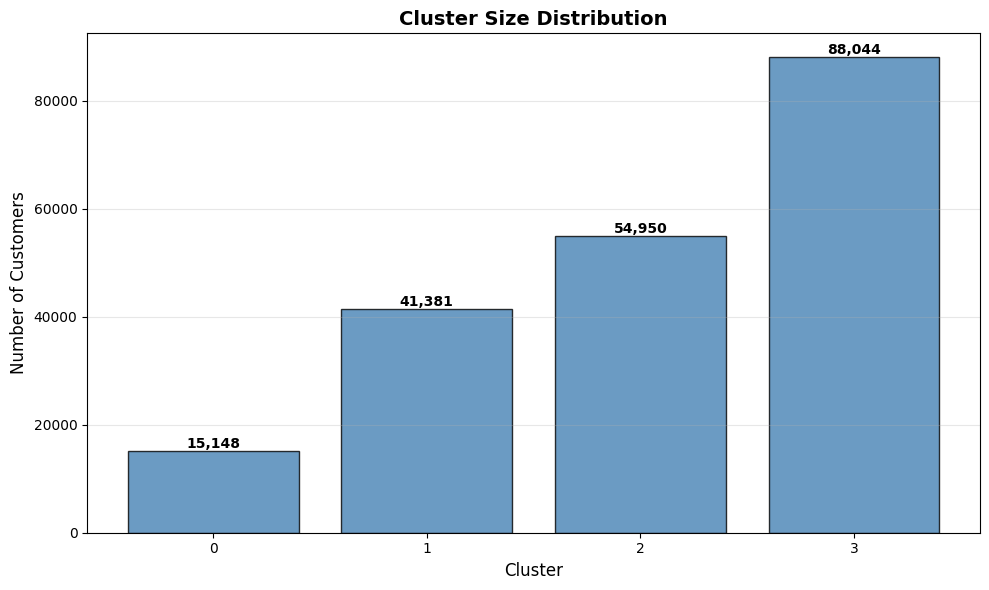

In [27]:
plt.figure(figsize=(10, 6))
cluster_sizes = df['cluster'].value_counts().sort_index()
bars = plt.bar(cluster_sizes.index, cluster_sizes.values, color='steelblue', alpha=0.8, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Cluster Size Distribution', fontsize=14, fontweight='bold')
plt.xticks(range(optimal_k))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Cluster Profile Analysis


Detailed profiling of each cluster including demographics, household structure, employment, industry, financial characteristics, and geographic distribution.

In [28]:
# Analyzing demographics of each cluster
print("DEMOGRAPHIC PROFILE BY CLUSTER")

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    print(f"\n{'-'*70}")
    print(f"CLUSTER {cluster} (n={len(cluster_data):,})")
    print('-'*70)
    
    if 'age_group' in df.columns:
        age_mode = cluster_data['age_group'].mode()[0]
        age_pct = (cluster_data['age_group'] == age_mode).sum() / len(cluster_data) * 100
        print(f"\nMost common age group: {age_mode} ({age_pct:.1f}%)")
        print("Top 3 age groups:")
        top_ages = cluster_data['age_group'].value_counts(normalize=True).head(3)
        for age, pct in top_ages.items():
            print(f"  {age}: {pct*100:.1f}%")
    
    if 'sex' in df.columns:
        gender_dist = cluster_data['sex'].value_counts(normalize=True)
        print(f"\nGender distribution:")
        for gender, pct in gender_dist.items():
            print(f"  {gender}: {pct*100:.1f}%")
    
    if 'marital stat' in df.columns:
        marital_mode = cluster_data['marital stat'].mode()[0]
        marital_pct = (cluster_data['marital stat'] == marital_mode).sum() / len(cluster_data) * 100
        print(f"\nMost common marital status: {marital_mode} ({marital_pct:.1f}%)")
        print("Marital status breakdown:")
        marital_dist = cluster_data['marital stat'].value_counts(normalize=True).head(3)
        for status, pct in marital_dist.items():
            print(f"  {status}: {pct*100:.1f}%")
    
    if 'race' in df.columns:
        race_mode = cluster_data['race'].mode()[0]
        race_pct = (cluster_data['race'] == race_mode).sum() / len(cluster_data) * 100
        print(f"\nMost common race: {race_mode} ({race_pct:.1f}%)")

DEMOGRAPHIC PROFILE BY CLUSTER

----------------------------------------------------------------------
CLUSTER 0 (n=15,148)
----------------------------------------------------------------------

Most common age group: 25-34 (21.6%)
Top 3 age groups:
  25-34: 21.6%
  35-44: 21.2%
  45-54: 15.5%

Gender distribution:
  Female: 54.4%
  Male: 45.6%

Most common marital status: Married-civilian spouse present (52.9%)
Marital status breakdown:
  Married-civilian spouse present: 52.9%
  Never married: 28.3%
  Widowed: 6.6%

Most common race: White (62.3%)

----------------------------------------------------------------------
CLUSTER 1 (n=41,381)
----------------------------------------------------------------------

Most common age group: 65+ (49.0%)
Top 3 age groups:
  65+: 49.0%
  55-64: 14.6%
  25-34: 9.7%

Gender distribution:
  Female: 66.6%
  Male: 33.4%

Most common marital status: Married-civilian spouse present (54.9%)
Marital status breakdown:
  Married-civilian spouse present: 54

In [29]:
#Economic Demographics Analysis

print("ECONOMIC & EMPLOYMENT PROFILE BY CLUSTER")

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    print(f"\n{'-'*70}")
    print(f"CLUSTER {cluster}")
    print('-'*70)
    
    if 'education_level' in df.columns:
        edu_mean = cluster_data['education_level'].mean()
        print(f"\nEducation level (mean): {edu_mean:.2f}")
        print("Education distribution (top 3):")
        print(cluster_data['education_level'].value_counts(normalize=True).head(3).apply(lambda x: f"{x*100:.1f}%"))

    if 'detailed household summary in household' in df.columns:
        print("\nHousehold Role Distribution (Top 3):")
        household_dist = cluster_data['detailed household summary in household'].value_counts(normalize=True).head(3)
        for role, pct in household_dist.items():
            count = (cluster_data['detailed household summary in household'] == role).sum()
            print(f"  {role}: {pct*100:.1f}% ({count:,} people)")
    
    if 'class of worker' in df.columns:
        worker_mode = cluster_data['class of worker'].mode()[0]
        worker_pct = (cluster_data['class of worker'] == worker_mode).sum() / len(cluster_data) * 100
        print(f"\nMost common worker class: {worker_mode} ({worker_pct:.1f}%)")
    
    if 'full or part time employment stat' in df.columns:
        employment_mode = cluster_data['full or part time employment stat'].mode()[0]
        employment_pct = (cluster_data['full or part time employment stat'] == employment_mode).sum() / len(cluster_data) * 100
        print(f"Employment status: {employment_mode} ({employment_pct:.1f}%)")
    
    if 'weeks worked in year' in df.columns:
        weeks_mean = cluster_data['weeks worked in year'].mean()
        print(f"Average weeks worked/year: {weeks_mean:.1f}")
    
    if 'is_self_employed' in df.columns:
        self_emp_pct = cluster_data['is_self_employed'].mean() * 100
        print(f"Self-employed: {self_emp_pct:.1f}%")

    if 'major industry code' in df.columns:
        print("\nTop 5 Industries:")
        industry_dist = cluster_data['major industry code'].value_counts(normalize=True).head(5)
        for industry, pct in industry_dist.items():
            count = (cluster_data['major industry code'] == industry).sum()
            print(f"  {industry}: {pct*100:.1f}% ({count:,} people)")
           
    veteran_mapping = {
    0: 'Eligible - No Benefits',
    1: 'Receives Benefits',
    2: 'Not Applicable/Never Served'}

    if 'veterans benefits' in df.columns:
        vet_counts = cluster_data['veterans benefits'].value_counts().sort_index()
        print("\nVeterans Benefits Status:")
        for code, label in veteran_mapping.items():
            if code in vet_counts.index:
                count = vet_counts[code]
                pct = (count / len(cluster_data)) * 100
                print(f"  {label}: {pct:.1f}% ({count:,} people)")
        
        receives_benefits = (cluster_data['veterans benefits'] == 1).sum()
        benefits_pct = (receives_benefits / len(cluster_data)) * 100
        print(f"\nActively receiving benefits: {benefits_pct:.1f}% ({receives_benefits:,} people)")


ECONOMIC & EMPLOYMENT PROFILE BY CLUSTER

----------------------------------------------------------------------
CLUSTER 0
----------------------------------------------------------------------

Education level (mean): 8.49
Education distribution (top 3):
education_level
9     25.4%
13    13.9%
10    13.6%
Name: proportion, dtype: object

Household Role Distribution (Top 3):
  Householder: 45.2% (6,847 people)
  Spouse of householder: 26.4% (3,996 people)
  Other relative of householder: 8.8% (1,334 people)

Most common worker class: Private (45.3%)
Employment status: Children or Armed Forces (51.4%)
Average weeks worked/year: 27.0
Self-employed: 7.3%

Top 5 Industries:
  Not in universe or children: 41.9% (6,344 people)
  Retail trade: 10.2% (1,545 people)
  Manufacturing-durable goods: 5.6% (843 people)
  Manufacturing-nondurable goods: 5.1% (776 people)
  Business and repair services: 4.4% (663 people)

Veterans Benefits Status:
  Eligible - No Benefits: 5.3% (798 people)
  Receives

In [30]:
print("FINANCIAL PROFILE BY CLUSTER")

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    print(f"\n{'-'*70}")
    print(f"CLUSTER {cluster}")
    print('-'*70)
    
    # Income indicators
    if 'wage_per_hour_capped' in df.columns:
        wage_mean = cluster_data['wage_per_hour_capped'].mean()
        wage_median = cluster_data['wage_per_hour_capped'].median()
        print(f"\nAverage hourly wage: ${wage_mean:.2f}")
    
    if 'net_capital' in df.columns:
        capital_mean = cluster_data['net_capital'].mean()
        capital_median = cluster_data['net_capital'].median()
        capital_positive_pct = (cluster_data['net_capital'] > 0).sum() / len(cluster_data) * 100
        print(f"\nAverage net capital: ${capital_mean:,.0f}")
    
    if 'dividends_capped' in df.columns:
        div_mean = cluster_data['dividends_capped'].mean()
        div_positive_pct = (cluster_data['dividends_capped'] > 0).sum() / len(cluster_data) * 100
        print(f"\nAverage dividends: ${div_mean:,.0f}")
        print(f"% receiving dividends: {div_positive_pct:.1f}%")

FINANCIAL PROFILE BY CLUSTER

----------------------------------------------------------------------
CLUSTER 0
----------------------------------------------------------------------

Average hourly wage: $51.88

Average net capital: $500

Average dividends: $120
% receiving dividends: 8.0%

----------------------------------------------------------------------
CLUSTER 1
----------------------------------------------------------------------

Average hourly wage: $0.69

Average net capital: $191

Average dividends: $406
% receiving dividends: 14.8%

----------------------------------------------------------------------
CLUSTER 2
----------------------------------------------------------------------

Average hourly wage: $2.57

Average net capital: $0

Average dividends: $2
% receiving dividends: 0.3%

----------------------------------------------------------------------
CLUSTER 3
----------------------------------------------------------------------

Average hourly wage: $112.19

Averag

In [31]:
print("GEOGRAPHIC & CULTURAL PROFILE BY CLUSTER")

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    print(f"\n{'-'*70}")
    print(f"CLUSTER {cluster}")
    print('-'*70)
    
    if 'country_of_birth_self_region' in df.columns:
        print("\nTop 3 birth regions:")
        top_regions = cluster_data['country_of_birth_self_region'].value_counts(normalize=True).head(3)
        for region, pct in top_regions.items():
            print(f"  {region}: {pct*100:.1f}%")
    
    if 'hispanic_origin' in df.columns:
        hispanic_dist = cluster_data['hispanic_origin'].value_counts(normalize=True).head(2)
        print("\nHispanic origin:")
        for origin, pct in hispanic_dist.items():
            print(f"  {origin}: {pct*100:.1f}%")


GEOGRAPHIC & CULTURAL PROFILE BY CLUSTER

----------------------------------------------------------------------
CLUSTER 0
----------------------------------------------------------------------

Top 3 birth regions:
  Latin_America_Caribbean: 37.5%
  Unknown: 22.2%
  Asia: 20.1%

----------------------------------------------------------------------
CLUSTER 1
----------------------------------------------------------------------

Top 3 birth regions:
  North_America: 99.9%
  Asia: 0.1%
  Other: 0.0%

----------------------------------------------------------------------
CLUSTER 2
----------------------------------------------------------------------

Top 3 birth regions:
  North_America: 98.8%
  Asia: 0.7%
  Latin_America_Caribbean: 0.4%

----------------------------------------------------------------------
CLUSTER 3
----------------------------------------------------------------------

Top 3 birth regions:
  North_America: 99.8%
  Asia: 0.2%


In [32]:
# A summary comparison table across all clusters
print("\n" + "-"*70)
print("CLUSTER COMPARISON SUMMARY")
print("-"*70)

summary_data = []

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    
    summary = {
        'Cluster': cluster,
        'Size': len(cluster_data),
        'Size %': f"{len(cluster_data)/len(df)*100:.1f}%"
    }
    
    # Age 
    if 'age_group' in df.columns:
        summary['Top Age Group'] = cluster_data['age_group'].mode()[0]
    
    # Education 
    if 'education_level' in df.columns:
        if pd.api.types.is_numeric_dtype(cluster_data['education_level']):
            summary['Avg Education'] = f"{cluster_data['education_level'].mean():.2f}"
        else:
            summary['Top Education'] = cluster_data['education_level'].mode()[0]
    
    # Financial metrics 
    if 'wage_per_hour_capped' in df.columns:
        summary['Avg Wage'] = f"${cluster_data['wage_per_hour_capped'].mean():.2f}"
    
    if 'net_capital' in df.columns:
        summary['Avg Capital'] = f"${cluster_data['net_capital'].mean():,.0f}"
    
    if 'weeks_worked_in_year' in df.columns:
        summary['Avg Weeks Worked'] = f"{cluster_data['weeks_worked_in_year'].mean():.1f}"
    
    # Demographics
    if 'sex' in df.columns:
        summary['Top Gender'] = cluster_data['sex'].mode()[0]
    
    if 'marital_stat' in df.columns:
        summary['Top Marital'] = cluster_data['marital_stat'].mode()[0]
    
    summary_data.append(summary)

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))



----------------------------------------------------------------------
CLUSTER COMPARISON SUMMARY
----------------------------------------------------------------------


 Cluster  Size Size % Top Age Group Avg Education Avg Wage Avg Capital Top Gender
       0 15148   7.6%         25-34          8.49   $51.88        $500     Female
       1 41381  20.7%           65+          8.37    $0.69        $191     Female
       2 54950  27.5%           <18          0.83    $2.57          $0       Male
       3 88044  44.1%         35-44         10.10  $112.19        $725       Male


In [33]:
print("\n" + "-"*70)
print("STATISTICAL SIGNIFICANCE TESTS")
print("-"*70)

numerical_test_cols = []

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]) and col != 'cluster':
        numerical_test_cols.append(col)

print(f"\nTesting {len(numerical_test_cols)} numerical features:")
print("-" * 70)

for col in numerical_test_cols:
    groups = [df[df['cluster'] == i][col].dropna() for i in sorted(df['cluster'].unique())]
    
    if any(len(g) == 0 for g in groups):
        continue

    f_stat, p_value = stats.f_oneway(*groups)
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    print(f"{col:35s} F={f_stat:8.2f}  p={p_value:.6f}  {significance}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")



----------------------------------------------------------------------
STATISTICAL SIGNIFICANCE TESTS
----------------------------------------------------------------------

Testing 19 numerical features:
----------------------------------------------------------------------
age                                 F=110665.14  p=0.000000  ***
detailed industry recode            F=102432.82  p=0.000000  ***
wage per hour                       F= 2678.31  p=0.000000  ***
capital gains                       F=  353.40  p=0.000000  ***
capital losses                      F=  576.47  p=0.000000  ***
dividends from stocks               F=  441.87  p=0.000000  ***
weight                              F=  383.68  p=0.000000  ***
num persons worked for employer     F=60616.16  p=0.000000  ***
own business or self employed       F= 6283.95  p=0.000000  ***
veterans benefits                   F=223032.90  p=0.000000  ***
weeks worked in year                F=188499.32  p=0.000000  ***
year           

## Cluster Summary and Naming


Creating meaningful segment names and final summary table for business stakeholders.

In [34]:
cluster_names = {
    0: "Students & Entry-Level Workers",
    1: "Senior Citizens", 
    2: "Children or minors",
    3: "Adults with Families",
}

df['cluster_name'] = df['cluster'].map(cluster_names)

summary_data = []

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    
    summary_data.append({
        'Cluster': cluster,
        'Segment Name': cluster_names.get(cluster, f'Cluster {cluster}'),
        'Percentage': f"{(len(cluster_data) / len(df) * 100):.1f}%",
        'Most Common Age Group': cluster_data['age_group'].mode()[0] if 'age_group' in df.columns else 'N/A',
        'Avg Hourly Wage': f"${cluster_data['wage_per_hour_capped'].mean():.2f}" if 'wage_per_hour_capped' in df.columns else 'N/A'
    })

summary_df = pd.DataFrame(summary_data)

print("CUSTOMER SEGMENTATION SUMMARY")

print()
display(summary_df)
print()
print(f"Total Records: {len(df):,}")
print(f"Number of Segments: {df['cluster'].nunique()}")

CUSTOMER SEGMENTATION SUMMARY



,Cluster,Segment Name,Percentage,Most Common Age Group,Avg Hourly Wage
0,0,Students & Entry-Level Workers,7.6%,25-34,$51.88
1,1,Senior Citizens,20.7%,65+,$0.69
2,2,Children or minors,27.5%,<18,$2.57
3,3,Adults with Families,44.1%,35-44,$112.19



Total Records: 199,523
Number of Segments: 4


## Conclusion